In [1]:
import pandas as pd
import spacy
from collections import Counter
import matplotlib.pyplot as plt
from transformers import pipeline

from sklearn.cluster import KMeans
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
import pandas as pd
import matplotlib.pyplot as plt
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords


/home/moraa-ontita/Documents/Machine-learning/talent_survey/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[nltk_data] Downloading package stopwords to /home/moraa-
[nltk_data]     ontita/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [2]:
url = "https://docs.google.com/spreadsheets/d/1TBZLJ0Jcs6F1ZmB91X1GebCOl9qBAkRufEMeojmKugo/export?format=csv"
df = pd.read_csv(url)

# Example analysis
df.head() 


,date,title,category,story
0,2023-10-05,"As its workers strike, Kaiser Permanente strik...",Biotech & Health,"Yesterday, 75,000 workers at healthcare giant ..."
1,2022-11-11,Sight Tech Global 2022 agenda announced,Biotech & Health,"The third annual Sight Tech Global conference,..."
2,2023-07-12,UK femtech Daye launches virtual clinic for pe...,Biotech & Health,U.K. women’s health Daye has a new string to i...
3,2024-05-02,Peloton to lay off 400 employees as CEO Barry ...,Biotech & Health,"Peloton, the exercise equipment maker and onli..."
4,2024-01-09,Smart ring maker Ultrahuman announces tracker ...,Gadgets,Indian wearable startup Ultrahuman is getting ...


In [3]:
df.describe() # Get summary statistics

,date,title,category,story
count,150,150,150,150
unique,131,150,12,150
top,2022-10-27,"As its workers strike, Kaiser Permanente strik...",Biotech & Health,"Yesterday, 75,000 workers at healthcare giant ..."
freq,3,1,93,1


# Q1.

**Entity Recognition** or Named Entity Recognition (NER) is a sub-task of Natural Language Processing (NLP). NER involes locating and classifying names or words into predefined categories. This categories may include people, organization, Dates, geopolitical locations and so on. The benefit of this step in the NLP is it helps machine understand what entities are being referred to in unstructured text.

# Q2.

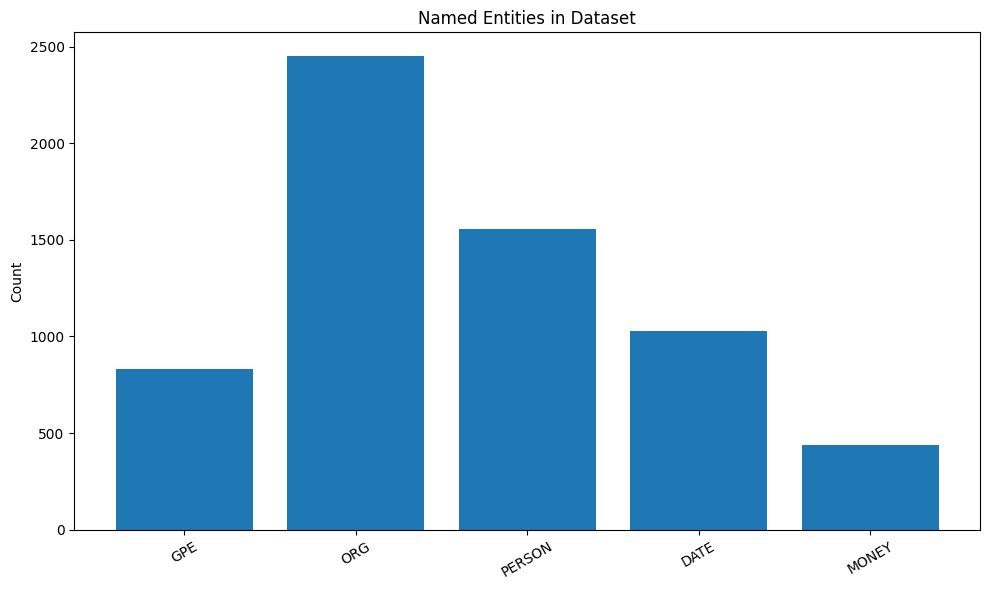


Sample GPE entities:
['Vancouver', 'LH', 'Purplle', 'Winnebago', 'Iraq', 'biotech', 'Poland', 'MD', 'Pelago', 'Abasi']

Sample ORG entities:
['Eli Lilly', 'AWS', 'Global Innovation', 'Sequoia', 'Elemental Cognition', 'Essential Capital', 'Halo', 'The Journal of Animal Science and Translational Animal Science', 'Isramco', 'Flatiron Health']

Sample PERSON entities:
['Tara Syed', 'Arman Zaribafiyan', 'Benjamina Bollag', 'Sandeep Gudibanda', 'Caju', 'Halo', 'Emily Ratajkowski', 'Jens von Bahr', 'Adam Rosendorff', 'Martin']

Sample DATE entities:
['early days', 'the following months', 'the last 10 to 15 years', 'a week', 'Today', '2023', 'three years ago', 'January 2, 2024', 'the past five years', 'two months']

Sample MONEY entities:
['$194 million', '$5.5 million', '#MicrosoftAtCES #', '£209 million', '$50 million', '211,000', '$2.3M', '20', '$8.5 million', '$75 million']


In [4]:
# Load spaCy model
nlp = spacy.load("en_core_web_sm")

# Combine all text for analysis
text = " ".join(df['story'].dropna().tolist())
doc = nlp(text)

# Automatically extract entities of interest (GPE, ORG, PERSON, DATE, MONEY)
entity_labels_of_interest = ["GPE", "ORG", "PERSON", "DATE", "MONEY"]
entity_counts = Counter([ent.label_ for ent in doc.ents if ent.label_ in entity_labels_of_interest])
entity_texts = {label: [ent.text for ent in doc.ents if ent.label_ == label] for label in entity_labels_of_interest}

# Plot counts
plt.figure(figsize=(10, 6))
plt.bar(entity_labels_of_interest, [entity_counts[label] for label in entity_labels_of_interest])
plt.title("Named Entities in Dataset")
plt.ylabel("Count")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

# (Optional) View examples
for label in entity_labels_of_interest:
    print(f"\nSample {label} entities:")
    print(list(set(entity_texts[label]))[:10])  # Show unique examples

# Analysis of "Named Entities in Dataset"
Overview: The histogram displays the count of named entities across five categories: GPE (Geopolitical Entities), ORG (Organizations), PERSON, DATE, and MONEY.

# Breakdown:
ORG: Highest count, approximately 2500.
PERSON: Second highest, around 1500.
DATE: Around 1000.
GPE: Around 750.
MONEY: Lowest count, around 500.

# Insights
**Dominance of Organizational Entities:**
"ORG" entities (2500) are the most frequent, suggesting the dataset heavily references organizations. This could indicate a focus on institutional data, such as companies, government agencies, or non-profits involved in the dataset’s context (e.g., project partners, stakeholders, or entities being studied).

**Prevalence of Person-Related Data:**
"PERSON" entities (1500) are the second most common, implying that individual names are significant in the dataset. This might reflect data involving people, such as employees, clients, or individuals impacted by the project (e.g., survey respondents, beneficiaries).

**Temporal Focus:**
"DATE" entities (1000) indicate a strong temporal component in the dataset. Dates are likely used to timestamp events, track progress, or record milestones, suggesting the dataset might be time-sensitive or event-driven.

**Geographic Relevance:**
"GPE" entities (750) show that locations (e.g., cities, countries) are referenced, but less frequently than organizations or people. This suggests the dataset has some geographic context, possibly indicating where events occur or where entities are located, but it’s not the primary focus.

**Financial Data as a Minor Component:**
"MONEY" entities (500) are the least common, indicating that financial figures (e.g., budgets, costs, transactions) are present but not a central theme. This could mean the project isn’t heavily focused on financial metrics, or such data is aggregated elsewhere.

# Implications
Project Context: The high count of "ORG" and "PERSON" entities suggests the project might involve collaboration between organizations and individuals, such as a study, survey, or operational initiative. The presence of "DATE" entities indicates a need to track timelines or schedules.

Data Usage: The dataset could be used for network analysis (e.g., mapping relationships between organizations and people), timeline analysis (using dates), or geographic mapping (using GPEs), though the latter would be less detailed due to fewer GPE entities.

Gaps: The low count of "MONEY" entities might indicate a gap if financial analysis is needed. Similarly, the moderate count of "GPE" entities suggests limited geographic granularity, which could hinder location-based insights.

# Recommendations
**Leverage Organizational and Person Data:**
Use the high counts of "ORG" and "PERSON" entities for network analysis or stakeholder mapping to understand relationships and roles within the project.

**Enhance Temporal Analysis:**
With 1000 "DATE" entities, create timelines or trend analyses to track project progress or identify key milestones.

**Supplement Geographic and Financial Data:**
If geographic or financial insights are needed, consider collecting more "GPE" and "MONEY" data to enable location-based or cost-related analysis.

# Data Structuring:
Organize the dataset to tag and categorize entities (e.g., ORG, PERSON) systematically, making it easier to query and analyze specific entity types.

# Conclusion
The dataset is rich in organizational ("ORG") and person-related ("PERSON") entities, with a notable temporal component ("DATE"). However, geographic ("GPE") and financial ("MONEY") entities are less frequent, suggesting the project focuses more on entities and timelines than on locations or finances. Leveraging the dominant entity types for relationship and timeline analysis, while addressing gaps in geographic and financial data, would maximize the dataset’s utility.

In [5]:
df.head()

,date,title,category,story
0,2023-10-05,"As its workers strike, Kaiser Permanente strik...",Biotech & Health,"Yesterday, 75,000 workers at healthcare giant ..."
1,2022-11-11,Sight Tech Global 2022 agenda announced,Biotech & Health,"The third annual Sight Tech Global conference,..."
2,2023-07-12,UK femtech Daye launches virtual clinic for pe...,Biotech & Health,U.K. women’s health Daye has a new string to i...
3,2024-05-02,Peloton to lay off 400 employees as CEO Barry ...,Biotech & Health,"Peloton, the exercise equipment maker and onli..."
4,2024-01-09,Smart ring maker Ultrahuman announces tracker ...,Gadgets,Indian wearable startup Ultrahuman is getting ...


# Q3

In [6]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import NMF
import nltk
from nltk.corpus import stopwords
import string

# Download NLTK stopwords
nltk.download('stopwords')
stop_words = stopwords.words('english')

# Preprocessing: Remove stopwords, punctuation, and lowercase the text
def preprocess_text(text):
    # Remove punctuation and convert to lowercase
    text = text.translate(str.maketrans('', '', string.punctuation)).lower()
    # Remove stopwords
    text = ' '.join([word for word in text.split() if word not in stop_words])
    return text

# Apply preprocessing to the story column
df['cleaned_story'] = df['story'].apply(preprocess_text)

# Vectorization using TF-IDF
vectorizer = TfidfVectorizer(max_df=0.95, min_df=2, stop_words='english')
X = vectorizer.fit_transform(df['cleaned_story'])

# Apply NMF for topic modeling
n_topics = 3
nmf = NMF(n_components=n_topics, random_state=42)
nmf.fit(X)

# Print the top words for each topic
def print_top_words(model, feature_names, n_words=10):
    for topic_idx, topic in enumerate(model.components_):
        print(f"Topic #{topic_idx + 1}:")
        print(" ".join([feature_names[i] for i in topic.argsort()[:-n_words - 1:-1]]))
        print("\n")

# Get feature names (terms) from the TF-IDF vectorizer
feature_names = vectorizer.get_feature_names_out()

# Print the top words for each topic
print_top_words(nmf, feature_names)

# Step 4: Optionally, you can display the topic distribution for each document
topic_distribution = nmf.transform(X)

# Show the topic distribution for each document
df['topic_distribution'] = topic_distribution.tolist()

# Display the DataFrame with the topic distribution
print("\nTopic Distribution for each document:")
print(df[['date', 'title', 'topic_distribution']])


[nltk_data] Downloading package stopwords to /home/moraa-
[nltk_data]     ontita/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Topic #1:
health healthcare care company million said patients startup platform mental


Topic #2:
protein proteins meat sequence foods cultivated company cells molecules production


Topic #3:
ai models data language voice like drug model startup tech



Topic Distribution for each document:
           date                                              title  \
0    2023-10-05  As its workers strike, Kaiser Permanente strik...   
1    2022-11-11            Sight Tech Global 2022 agenda announced   
2    2023-07-12  UK femtech Daye launches virtual clinic for pe...   
3    2024-05-02  Peloton to lay off 400 employees as CEO Barry ...   
4    2024-01-09  Smart ring maker Ultrahuman announces tracker ...   
..          ...                                                ...   
145  2024-04-05  Varda Space’s orbital drug factory success fue...   
146  2023-04-06  Nestlé takes a big swig of Yfood in a deal tha...   
147  2023-03-30  UPDATED: Smoakland is testing a loophole to se...   
148  2

In [7]:
df[['date', 'title', 'topic_distribution']]

,date,title,topic_distribution
0,2023-10-05,"As its workers strike, Kaiser Permanente strik...","[0.03856907917573532, 0.0, 0.22510548331319247]"
1,2022-11-11,Sight Tech Global 2022 agenda announced,"[0.0, 0.0, 0.4033254435320784]"
2,2023-07-12,UK femtech Daye launches virtual clinic for pe...,"[0.15683193958740638, 0.0, 0.005663868835897158]"
3,2024-05-02,Peloton to lay off 400 employees as CEO Barry ...,"[0.09954494524964105, 0.011574002888375446, 0...."
4,2024-01-09,Smart ring maker Ultrahuman announces tracker ...,"[0.09171522412416194, 0.0, 0.09863062429488755]"
...,...,...,...
145,2024-04-05,Varda Space’s orbital drug factory success fue...,"[0.0689189495941304, 0.1621554679108288, 0.080..."
146,2023-04-06,Nestlé takes a big swig of Yfood in a deal tha...,"[0.12880443300803027, 0.04697142532066111, 0.0..."
147,2023-03-30,UPDATED: Smoakland is testing a loophole to se...,"[0.08119339195598796, 0.03871877716284304, 0.0..."
148,2023-11-17,Toku’s AI platform predicts heart conditions b...,"[0.10624538695682988, 0.0, 0.198673466977358]"


# Topic #1: Healthcare and Health Technology
Key Words: health, healthcare, care, company, million, patients, startup, platform, mental, health-related terms.

## Thematic Focus: 
This topic revolves around the healthcare industry, including healthcare providers, startups in health tech, patient care, and mental health. The authors are likely discussing advancements in healthcare, major events like healthcare strikes, new health platforms, and innovations in patient care.

# Topic #2: Food Technology and Biotechnology
Key Words: protein, proteins, meat, sequence, foods, cultivated, company, cells, molecules, production.

## Thematic Focus: 
This topic focuses on the intersection of biotechnology and food. The articles likely cover topics like lab-grown meat, plant-based proteins, food sustainability, biotechnology companies producing novel food products, and scientific breakthroughs in food science.

# Topic #3: AI and Technology
Key Words: AI, models, data, language, voice, like, drug, model, startup, tech.

## Thematic Focus: 
This topic is centered on artificial intelligence (AI), technology startups, and innovations in data processing, language models, and AI applications in various industries, including healthcare (e.g., AI drug discovery or diagnostics). Authors are likely discussing advancements in AI technology, its potential impact, and its applications in various fields.

## Summary of Key Thematic Areas:
Healthcare and Health Technology – Topics like healthcare worker strikes, health startups, and patient care innovations.

Food Technology and Biotechnology – Discussions around the development of lab-grown meat, protein innovations, and food biotechnology.

AI and Technology – Focus on AI applications, models, startups, and technological advancements in various sectors, including healthcare and voice recognition.

These thematic areas suggest that the articles are covering a wide range of topics from healthcare advancements, biotech innovations, to the impact of AI and technology in various industries.

# Q4

In [8]:
df.head()

,date,title,category,story,cleaned_story,topic_distribution
0,2023-10-05,"As its workers strike, Kaiser Permanente strik...",Biotech & Health,"Yesterday, 75,000 workers at healthcare giant ...",yesterday 75000 workers healthcare giant kaise...,"[0.03856907917573532, 0.0, 0.22510548331319247]"
1,2022-11-11,Sight Tech Global 2022 agenda announced,Biotech & Health,"The third annual Sight Tech Global conference,...",third annual sight tech global conference virt...,"[0.0, 0.0, 0.4033254435320784]"
2,2023-07-12,UK femtech Daye launches virtual clinic for pe...,Biotech & Health,U.K. women’s health Daye has a new string to i...,uk women’s health daye new string bow it’s ope...,"[0.15683193958740638, 0.0, 0.005663868835897158]"
3,2024-05-02,Peloton to lay off 400 employees as CEO Barry ...,Biotech & Health,"Peloton, the exercise equipment maker and onli...",peloton exercise equipment maker online fitnes...,"[0.09954494524964105, 0.011574002888375446, 0...."
4,2024-01-09,Smart ring maker Ultrahuman announces tracker ...,Gadgets,Indian wearable startup Ultrahuman is getting ...,indian wearable startup ultrahuman getting sma...,"[0.09171522412416194, 0.0, 0.09863062429488755]"


In [ ]:
# Load the summarization pipeline
summarizer = pipeline("summarization", model="facebook/bart-large-cnn")

# Function to summarize a single text
def summarize_text(text):
    # Skip if text is too short
    if not isinstance(text, str) or len(text.split()) < 30:
        return text  # Return original if it's too short
    try:
        summary = summarizer(text, max_length=130, min_length=30, do_sample=False)[0]['summary_text']
        return summary
    except Exception as e:
        print("Error:", e)
        return text

# Apply summarization to the 'story' column
df['summary'] = df['story'].apply(summarize_text)

# Save to CSV if needed
df.to_csv("summarized_articles.csv", index=False)

# Display first few summaries
print(df[['title', 'summary']].head())


# Q5

In [9]:
texts = df['cleaned_story'].dropna().tolist()

# 2. Embed the texts
model = SentenceTransformer('all-MiniLM-L6-v2')
embeddings = model.encode(texts)

# 3. Cluster using KMeans (10 clusters for 10 categories)
kmeans = KMeans(n_clusters=10, random_state=42)
df['cluster'] = kmeans.fit_predict(embeddings)

# 4. Assign cluster labels manually or with similarity (optional helper)
categories = [
    "Advanced Gene Editing", "mRNA Technology", "CAR-T Cell Therapy",
    "Organoids and Tissue Engineering", "Single-Cell Genomics",
    "Synthetic Biology", "Biological Computing", "Wearable Biosensors",
    "Microbiome Therapeutics", "Nanomedicine"
]

# Optional: use the cluster centers and keyword descriptions to semi-automate label assignment
# For now, manually inspect top samples per cluster:
for i in range(10):
    print(f"\nCluster {i}")
    print(df[df['cluster'] == i]['cleaned_story'].head(3))

# 5. Manually map cluster IDs to categories
cluster_to_category = {
    0: "Wearable Biosensors",
    1: "Nanomedicine",
    2: "CAR-T Cell Therapy",
    3: "Advanced Gene Editing",
    4: "Microbiome Therapeutics",
    5: "mRNA Technology",
    6: "Single-Cell Genomics",
    7: "Synthetic Biology",
    8: "Organoids and Tissue Engineering",
    9: "Biological Computing"
}

df['category_predicted'] = df['cluster'].map(cluster_to_category)

# 6. Generate ratios
ratios = df['category_predicted'].value_counts(normalize=True).sort_index()
print("\nCategory Ratios:")
print(ratios)


Cluster 0
10    global cultured meat market poised reach half ...
22    canadian vertical farming startup adapt agtech...
25    nature done hell job last billion years there’...
Name: cleaned_story, dtype: object

Cluster 1
27    disgraced founder theranos elizabeth holmes se...
51    critics flaming new york times posting earlier...
89    combinator renowned silicon valley lot reasons...
Name: cleaned_story, dtype: object

Cluster 2
8     there’s new generative ai startup based paris ...
9     israeli biotech startup manabio planning launc...
18    founded 2017 bionaut labs arrived stealth marc...
Name: cleaned_story, dtype: object

Cluster 3
2     uk women’s health daye new string bow it’s ope...
13    joanna strober around 47 stopped sleeping losi...
14    inito yc alum helps women track fertility horm...
Name: cleaned_story, dtype: object

Cluster 4
3     peloton exercise equipment maker online fitnes...
7     welcome back found get stories behind startups...
15    cat scared may 

In [10]:
df.head()

,date,title,category,story,cleaned_story,topic_distribution,cluster,category_predicted
0,2023-10-05,"As its workers strike, Kaiser Permanente strik...",Biotech & Health,"Yesterday, 75,000 workers at healthcare giant ...",yesterday 75000 workers healthcare giant kaise...,"[0.03856907917573532, 0.0, 0.22510548331319247]",9,Biological Computing
1,2022-11-11,Sight Tech Global 2022 agenda announced,Biotech & Health,"The third annual Sight Tech Global conference,...",third annual sight tech global conference virt...,"[0.0, 0.0, 0.4033254435320784]",7,Synthetic Biology
2,2023-07-12,UK femtech Daye launches virtual clinic for pe...,Biotech & Health,U.K. women’s health Daye has a new string to i...,uk women’s health daye new string bow it’s ope...,"[0.15683193958740638, 0.0, 0.005663868835897158]",3,Advanced Gene Editing
3,2024-05-02,Peloton to lay off 400 employees as CEO Barry ...,Biotech & Health,"Peloton, the exercise equipment maker and onli...",peloton exercise equipment maker online fitnes...,"[0.09954494524964105, 0.011574002888375446, 0....",4,Microbiome Therapeutics
4,2024-01-09,Smart ring maker Ultrahuman announces tracker ...,Gadgets,Indian wearable startup Ultrahuman is getting ...,indian wearable startup ultrahuman getting sma...,"[0.09171522412416194, 0.0, 0.09863062429488755]",6,Single-Cell Genomics


# Q6

Topic 0 - Biotech Scandals & Digital Health:
new | people | round | urine | digital | theranos | said | health | holmes | company

Topic 1 - AI & Generative Models:
new | training | image | data | voice | language | model | like | models | ai

Topic 2 - AI in Healthcare Startups:
data | ai | new | said | million | patients | healthcare | also | startup | health

Topic 3 - Health Investment & Platforms:
health | investors | new | 54gene | business | amazon | said | also | million | company

Topic 4 - Drug Development & Biotech Startups:
investors | million | adapt | round | also | startup | market | drug | company | said

Topic 5 - Mental Health & Digital Therapeutics:
million | therapy | mental | healthcare | new | one | said | company | care | health

Topic 6 - Tech & Bio Convergence:
people | said | technology | like | tech | protein | also | new | ai | company

Topic 7 - Imaging, Tracking & Sensors:
image | credits | tracking | years | also | like | million | health | said | company

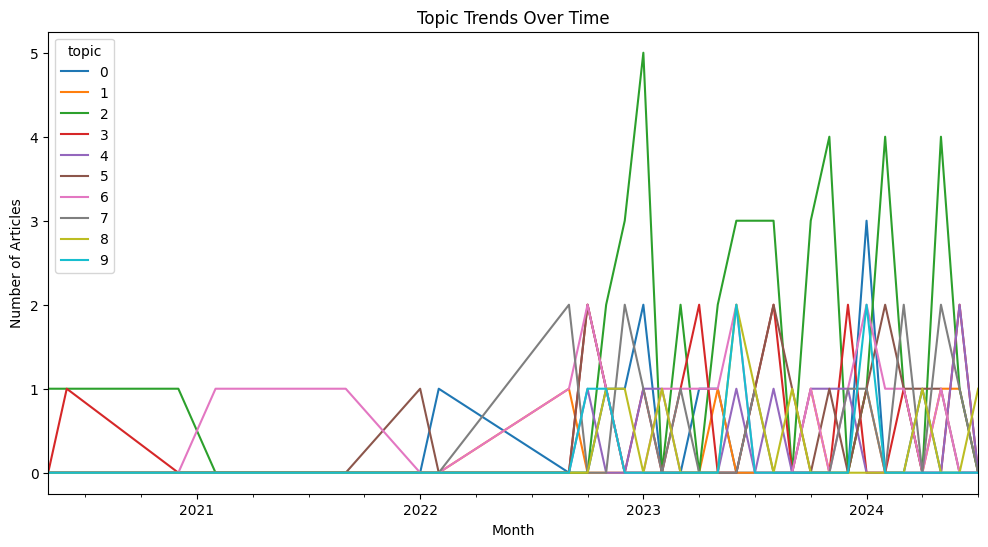

In [11]:
# Load data
texts = df['cleaned_story'].dropna().tolist()

# Vectorize
vectorizer = CountVectorizer(stop_words=stopwords.words('english'), max_df=0.95, min_df=2)
X = vectorizer.fit_transform(texts)

# LDA model
lda = LatentDirichletAllocation(n_components=10, random_state=42)
lda.fit(X)

# Display top keywords for each topic with a topic name
def print_topics_with_names(model, vectorizer, top_n=10):
    topic_names = [
        "Biotech Scandals & Digital Health",
        "AI & Generative Models",
        "AI in Healthcare Startups",
        "Health Investment & Platforms",
        "Drug Development & Biotech Startups",
        "Mental Health & Digital Therapeutics",
        "Tech & Bio Convergence",
        "Imaging, Tracking & Sensors",
        "Alternative Proteins & Food Biotech",
        "COVID, Calm Apps, and Lifestyle Biotech"
    ]
    
    for idx, topic in enumerate(model.components_):
        print(f"Topic {idx} - {topic_names[idx]}:")
        print(" | ".join([vectorizer.get_feature_names_out()[i] for i in topic.argsort()[-top_n:]]))
        print()

print_topics_with_names(lda, vectorizer)

# Assign topic to each document
topic_values = lda.transform(X)
df['topic'] = topic_values.argmax(axis=1)

# Optional: Topic trend over time
df['date'] = pd.to_datetime(df['date'])
df['month'] = df['date'].dt.to_period('M')
trend = df.groupby(['month', 'topic']).size().unstack().fillna(0)
trend.plot(figsize=(12, 6), title="Topic Trends Over Time")
plt.xlabel("Month")
plt.ylabel("Number of Articles")
plt.show()


# Overview
Graph Details: The x-axis represents time (months from 2021 to 2024), and the y-axis shows the number of articles (0 to 5). Each line corresponds to one of the 10 topics (0 to 9), with distinct colors for each topic.

# Topics:
Topic 0: Biotech Scandals & Digital Health (e.g., Theranos, Holmes)
Topic 1: AI & Generative Models (e.g., AI models, language)
Topic 2: AI in Healthcare Startups (e.g., healthcare AI, startups)
Topic 3: Health Investment & Platforms (e.g., 54gene, Amazon)
Topic 4: Drug Development & Biotech Startups (e.g., drug development)
Topic 5: Mental Health & Digital Therapeutics (e.g., mental health, therapy)
Topic 6: Tech & Bio Convergence (e.g., tech, protein, AI)
Topic 7: Imaging, Tracking & Sensors (e.g., imaging, sensors)
Topic 8: Alternative Proteins & Food Biotech (e.g., proteins, meat)
Topic 9: COVID, Calm Apps, and Lifestyle Biotech (e.g., COVID, Calm)

# Analysis
**Overall Trends:**
From 2021 to mid-2022, the number of articles across all topics is low (0-1 articles per month), indicating limited coverage or interest.
A significant spike occurs in mid-2023, with several topics reaching peaks of 3-5 articles per month, suggesting a surge in interest or events related to these topics.
After mid-2023, the number of articles fluctuates but generally remains higher than in 2021-2022, with frequent peaks and troughs through 2024.

**Topic-Specific Trends:**
Topic 0 (Biotech Scandals & Digital Health, Red Line):
Starts with a small peak in early 2021 (around 1 article), likely tied to ongoing discussions about Theranos and Elizabeth Holmes, whose trial concluded around late 2021.
Remains low until mid-2023, then spikes to around 3 articles during the 2023 surge, possibly due to renewed interest in digital health scandals or innovations.

**Topic 1 (AI & Generative Models, Blue Line):**
Low activity until mid-2023, then shows multiple peaks (up to 4 articles), reflecting growing interest in AI models, possibly driven by advancements in generative AI (e.g., ChatGPT, DALL-E).
Continues to fluctuate in 2024, indicating sustained interest.

**Topic 2 (AI in Healthcare Startups, Green Line):**
Peaks dramatically in mid-2023, reaching 5 articles, the highest of any topic. This suggests a major event or trend in AI healthcare startups, possibly funding rounds or breakthroughs.
Remains active with smaller peaks in 2024, showing ongoing relevance.

**Topic 3 (Health Investment & Platforms, Purple Line):**
Steady but low activity (0-1 articles) until mid-2023, then spikes to around 3 articles. This could be linked to investments in platforms like 54gene or Amazon’s healthcare initiatives.
Fluctuates in 2024, indicating periodic interest.

**Topic 4 (Drug Development & Biotech Startups, Pink Line):**
Low activity until mid-2023, then peaks at around 3 articles. Likely driven by funding rounds or drug development milestones in biotech startups.
Consistent fluctuations in 2024, suggesting steady but not dominant interest.

**Topic 5 (Mental Health & Digital Therapeutics, Brown Line):**
Small peaks in 2021-2022 (around 1 article), possibly tied to growing awareness of mental health during the pandemic.
Spikes to 3 articles in mid-2023, reflecting interest in digital therapeutics, then fluctuates in 2024.

**Topic 6 (Tech & Bio Convergence, Gray Line):**
Low activity until mid-2023, then peaks at around 3 articles. Likely driven by advancements in tech-bio integration (e.g., AI in protein design).
Fluctuates in 2024, showing moderate interest.

**Topic 7 (Imaging, Tracking & Sensors, Yellow Line):**
Minimal activity throughout, with small peaks (1-2 articles) in 2023 and 2024. Indicates niche but consistent interest in imaging and sensor technologies.

**Topic 8 (Alternative Proteins & Food Biotech, Cyan Line):**
Low activity with occasional small peaks (1 article) in 2023 and 2024. Suggests alternative proteins and food biotech are not a major focus but have periodic relevance.

**Topic 9 (COVID, Calm Apps, and Lifestyle Biotech, Light Blue Line):**
Small peak in 2021 (around 1 article), likely tied to COVID-related discussions or Calm app usage during the pandemic. Low activity afterward, with minor peaks in 2023 and 2024, indicating fading interest in COVID-related lifestyle biotech.

# Insights
**Mid-2023 Surge:**
The significant spike in mid-2023 across multiple topics (especially Topics 1, 2, 3, 4, 5, and 6) suggests a broader trend or event in the biotech and health tech space. This could be due to a major industry conference, a wave of funding announcements, or technological breakthroughs (e.g., generative AI impacting healthcare and biotech).

**Dominant Topics:**
Topic 2 (AI in Healthcare Startups) peaks the highest (5 articles), indicating strong interest in AI-driven healthcare innovations, likely fueled by startups securing funding or launching new solutions.
Topic 1 (AI & Generative Models) and Topic 3 (Health Investment & Platforms) also show significant activity, reflecting the growing intersection of AI, healthcare, and investment.

**Niche Topics:**
Topic 7 (Imaging, Tracking & Sensors) and Topic 8 (Alternative Proteins & Food Biotech) have the least activity, suggesting these areas are less mainstream or slower to gain traction in this dataset.
Topic 9 (COVID, Calm Apps, and Lifestyle Biotech) sees early interest in 2021 but fades, likely as COVID-related topics become less urgent by 2023-2024.

**Sustained Interest:**
Topics 1, 2, 3, 4, and 6 maintain fluctuations in 2024, indicating sustained interest in AI, healthcare startups, investments, drug development, and tech-bio convergence. Mental health (Topic 5) also shows periodic spikes, reflecting ongoing relevance.

# Recommendations
**Focus on High-Interest Areas:**
Prioritize research or investment in AI in Healthcare Startups (Topic 2) and AI & Generative Models (Topic 1), as they show the strongest and most sustained interest. These areas are likely driving innovation and attracting attention.

**Monitor Investment Trends:**
Topic 3 (Health Investment & Platforms) indicates periodic spikes in investment activity. Tracking companies like 54gene or Amazon’s healthcare initiatives could provide insights into emerging opportunities.

**Explore Niche Growth:**
Topic 8 (Alternative Proteins & Food Biotech) and Topic 7 (Imaging, Tracking & Sensors) are niche but show occasional interest. These areas might be worth exploring for early opportunities in food biotech or health tech sensors.

**Address Fading Topics:**
Topic 9 (COVID, Calm Apps, and Lifestyle Biotech) is losing relevance. Shift focus from COVID-related lifestyle biotech to more current trends like AI and mental health therapeutics.

**Investigate the 2023 Spike:**
Dig deeper into the mid-2023 surge to identify specific events (e.g., funding rounds, product launches, or policy changes) that drove interest across multiple topics. This could inform future strategies.

# Conclusion
The "Topic Trends Over Time" graph shows a clear surge in interest in biotech and health tech topics in mid-2023, with AI in healthcare startups, generative AI, and health investments leading the way. While some topics like alternative proteins and COVID-related lifestyle biotech remain niche or fade, areas like mental health and tech-bio convergence show sustained relevance. Focusing on high-interest areas like AI and healthcare startups, while monitoring niche topics for growth, would align with the observed trends.

# Overall Dataset Conclusion

The dataset presents a dynamic snapshot of developments in the biotech, health tech, and AI sectors, reflecting varying levels of interest and activity over time. Key findings highlight a growing trend in AI-driven healthcare innovations, biotech scandals, and digital health platforms, with a notable surge in attention around mid-2023.

# Key Insights:
Dominant Entities: 
The dataset predominantly revolves around organizational (ORG) and person-related (PERSON) entities, indicating a strong focus on collaborations between organizations, people, and institutional actors. This suggests the project likely involves studies, surveys, or operational initiatives involving key stakeholders in healthcare and biotech.

Temporal Trends: 
Date (DATE) entities show that the dataset is sensitive to time, with several milestones and events being tracked. The presence of these entities, along with the surge in topic activity mid-2023, suggests that temporal analysis can reveal important trends, such as industry shifts or specific events driving sector interest.

Niche Areas: 
Geopolitical (GPE) and financial (MONEY) entities are less frequent, indicating that while geographic and financial data are present, they are not the dataset's primary focus. Geographic relevance may be limited, and financial aspects seem to be more aggregated, suggesting that the project may not emphasize detailed location-based or cost-related insights.

# Trends in Topics:
AI & Healthcare Startups: 
The most notable trend is the dramatic spike in AI in healthcare startups (Topic 2), driven by significant advancements and funding rounds. The AI and generative models sector (Topic 1) also shows considerable growth, reflecting the increasing integration of AI in healthcare, biotech, and other sectors.

Health Investments & Platforms: 
The investment activity in health tech, particularly companies like 54gene and Amazon's healthcare initiatives (Topic 3), shows significant interest, with spikes tied to funding rounds and developments in health platforms.

Mental Health & Digital Therapeutics: 
The growing interest in mental health (Topic 5) suggests a rising focus on digital therapeutics and wellness tech, which continues to gain relevance in the post-pandemic landscape.

# Shifting Focus:
Some topics, such as alternative proteins (Topic 8) and COVID-related lifestyle biotech (Topic 9), show diminished activity over time, indicating fading relevance. These areas may have been more prominent earlier in the dataset but have since lost traction. However, they might still hold niche potential for early-stage opportunities or specialized research.

# Recommendations:
Focus on High-Interest Topics: 
Given the sustained attention on AI in healthcare startups and AI & generative models, these areas should be prioritized for future research or investment. They are expected to drive innovation and attract ongoing interest.

Monitor Investment Patterns: 
Tracking the investment trends seen in Health Investment & Platforms (Topic 3) could yield valuable insights, especially for identifying emerging startups and technologies.

Address Niche Opportunities: 
Niche topics such as imaging, tracking & sensors (Topic 7) and alternative proteins (Topic 8) may offer early-stage opportunities, even though they currently lack widespread attention.

Analyze Mid-2023 Surge: 
Investigating the factors behind the mid-2023 surge across several topics can uncover specific drivers—such as major product launches, industry conferences, or technological breakthroughs—that may shape the future of these sectors.

# Conclusion Summary:

The dataset illustrates a growing intersection of AI, healthcare, and biotech, with key trends centered around startups, innovation, and investments. The surge in mid-2023 highlights a pivotal moment in these industries, while the focus on AI in healthcare and mental health tech signals future directions. By aligning research or investment efforts with these high-interest areas and exploring niche opportunities, stakeholders can capitalize on emerging trends in the biotech and health tech ecosystems.